In [26]:
%load_ext autoreload
%autoreload 2

import os
import glob
from pathlib import Path
import sys
import pyarrow
import pandas as pd


PROJECT_ROOT = Path().resolve().parent
sys.path.append(str(PROJECT_ROOT))

from src.config.config import DATA_RAW,DATA_PROCESSED, DATA_FEATURES
from src.loaders.csv_loader import CSVLoader
from src.repository.parquet_repository import ParquetRepository

from src.dataProcessing.data_quality import DataQuality
from src.dataProcessing.data_features import DataFeatures
from src.dataProcessing.data_quality_features import DataQualityFeatures
from src.visualization.TimeBoxplot import SalesTimeBoxplot
from src.visualization.TimeViolin import SalesTimeViolin
from src.visualization.TimeOutlier import SalesTimeOutlier
from src.visualization.ProductQuantityHistogram import ProductQuantityHistogram



csvLoader = CSVLoader()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
repo = ParquetRepository(DATA_PROCESSED)

In [3]:
df_processed = repo.load("beverage_sales_processed_qa_ok.parquet")

[OK] Arquivo carregado: D:\PROJETOS\git_repo\BEVERAGE-SALES\data\processed\beverage_sales_processed_qa_ok.parquet


In [4]:
df_processed.head(10)

,Order_ID,Customer_ID,Customer_Type,Product,Category,Unit_Price,Quantity,Discount,Total_Price,Region,Order_Date
0,ORD1,CUS1496,B2B,Vio Wasser,Water,1.66,53,0.10,79.18,Baden-Württemberg,2023-08-23
1,ORD1,CUS1496,B2B,Evian,Water,1.56,90,0.10,126.36,Baden-Württemberg,2023-08-23
2,ORD1,CUS1496,B2B,Sprite,Soft Drinks,1.17,73,0.05,81.14,Baden-Württemberg,2023-08-23
3,ORD1,CUS1496,B2B,Rauch Multivitamin,Juices,3.22,59,0.10,170.98,Baden-Württemberg,2023-08-23
4,ORD1,CUS1496,B2B,Gerolsteiner,Water,0.87,35,0.10,27.40,Baden-Württemberg,2023-08-23
5,ORD2,CUS2847,B2C,Sauvignon Blanc,Alcoholic Beverages,9.09,2,0.00,18.18,Schleswig-Holstein,2023-03-16
6,ORD3,CUS1806,B2B,Tomato Juice,Juices,2.14,44,0.10,84.74,Hamburg,2022-11-20
7,ORD3,CUS1806,B2B,Vittel,Water,0.43,13,0.05,5.31,Hamburg,2022-11-20
8,ORD3,CUS1806,B2B,San Pellegrino,Water,1.21,92,0.10,100.19,Hamburg,2022-11-20
9,ORD3,CUS1806,B2B,Evian,Water,1.38,3,0.05,3.93,Hamburg,2022-11-20


In [5]:
feature_builder = DataQualityFeatures(
    df=df_processed,
    date_col="Order_Date",
    group_cols=["Category","Product", "Region"],
    fill_missing_days=True
)

# Gera as features
df_features = feature_builder.build_all_features()

# Vamos supor que você queira verificar se ainda existe NaN
print(df_features[
    [
        "quantity_sum_std_7d",
        "total_price_sum_std_7d",
        "quantity_vs_mean_7d",
        "total_price_vs_mean_30d",
        "quantity_pct_vs_mean_7d"
    ]
].isna().sum())

quantity_sum_std_7d        0
total_price_sum_std_7d     0
quantity_vs_mean_7d        0
total_price_vs_mean_30d    0
quantity_pct_vs_mean_7d    0
dtype: int64


In [6]:
print (df_features.dtypes)

Order_Date                  datetime64[ns]
Category                            object
Product                             object
Region                              object
quantity_sum                       float64
total_price_sum                    float64
unit_price_mean                    float64
discount_mean                      float64
order_count                        float64
customer_count                     float64
avg_ticket                         float64
day_of_week                          int32
month                                int32
year                                 int32
is_weekend                           int64
quantity_sum_mean_7d               float64
quantity_sum_std_7d                float64
quantity_sum_sum_7d                float64
total_price_sum_mean_7d            float64
total_price_sum_std_7d             float64
total_price_sum_mean_30d           float64
unit_price_mean_mean_7d            float64
discount_mean_mean_14d             float64
quantity_vs

In [7]:
df_features.head(5)

,Order_Date,Category,Product,Region,quantity_sum,total_price_sum,unit_price_mean,discount_mean,order_count,customer_count,...,unit_price_mean_mean_7d,discount_mean_mean_14d,quantity_vs_mean_7d,total_price_vs_mean_30d,quantity_pct_vs_mean_7d,history_less_than_7d,history_less_than_30d,quantity_sum_next_7d,quantity_sum_next_14d,quantity_sum_next_30d
665151,2021-01-01,Water,Apollinaris,Baden-Württemberg,406.0,374.05,0.935000,0.033333,12.0,12.0,...,0.000000,0.000000,0.000000,0.000,0.000000,1,1,1937.0,4261.0,8557.0
665152,2021-01-02,Water,Apollinaris,Baden-Württemberg,384.0,322.81,0.870556,0.022222,18.0,17.0,...,0.935000,0.033333,-22.000000,-51.240,-0.054187,1,1,2032.0,4185.0,8537.0
665153,2021-01-03,Water,Apollinaris,Baden-Württemberg,292.0,263.65,0.918000,0.026667,15.0,15.0,...,0.902778,0.027778,-103.000000,-84.780,-0.260759,1,1,2068.0,4244.0,8644.0
665154,2021-01-04,Water,Apollinaris,Baden-Württemberg,326.0,250.35,0.883333,0.050000,9.0,9.0,...,0.907852,0.027407,-34.666667,-69.820,-0.096118,1,1,2065.0,4116.0,8662.0
665155,2021-01-05,Water,Apollinaris,Baden-Württemberg,202.0,190.74,0.893333,0.020833,12.0,12.0,...,0.901722,0.033056,-150.000000,-111.975,-0.426136,1,1,2233.0,4278.0,8865.0


In [8]:
report = feature_builder.run_full_analysis()
print(report)
print(feature_builder.generate_executive_summary())


                        rule_name issue_found  issue_count severity
0  Missing Derived Feature Values          NO            0     High
1     Negative Aggregated Metrics          NO            0   Medium
2       Invalid Calendar Features          NO            0      Low
Feature Quality Executive Summary
--------------------------------
Rules evaluated: 3
Rules with issues found: 0
Total issue count: 0
High-severity issues: No high-severity issues were detected



In [9]:
df1 = df_processed
df2 = df_features

In [10]:

df1["Order_Date"] = pd.to_datetime(df1["Order_Date"])
df2["Order_Date"] = pd.to_datetime(df2["Order_Date"])

In [13]:
df_final = pd.merge(
    df1,
    df2[[
        "Category",
        "Product",
        "Region",
        "Order_Date"
    ]],
    on=["Product", "Region", "Order_Date"],
    how="left"
)

In [15]:
df_final = pd.merge(
    df1,
    df2,
    on=["Category","Product", "Region", "Order_Date"],
    how="left"
)

In [16]:
print(df1.shape)
print(df2.shape)
print(df_final.shape)

(8999910, 11)
(822687, 31)
(8999910, 38)


In [17]:
print (df1.duplicated(subset=["Category","Product", "Region", "Order_Date"]).sum())
print (df_final.duplicated(subset=["Category","Product", "Region", "Order_Date"]).sum())

8177756
8177756


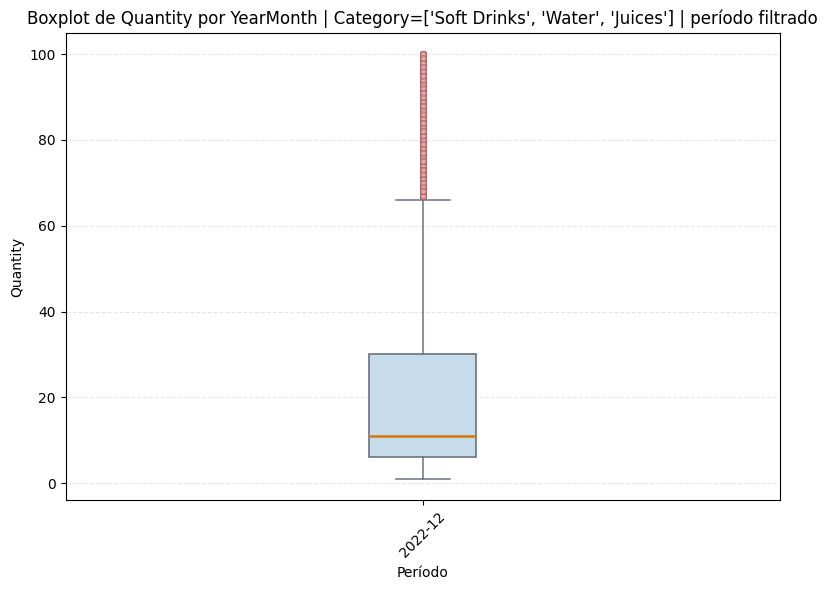

In [18]:
boxplot = SalesTimeBoxplot(df_final)

boxplot.plot_boxplot_by_period(
    value_col="Quantity",
    period="month",
    filters={
        "Category": ["Soft Drinks", "Water", "Juices"]
    },
    start_date="2022-12-01",
    end_date="2022-12-31"
)

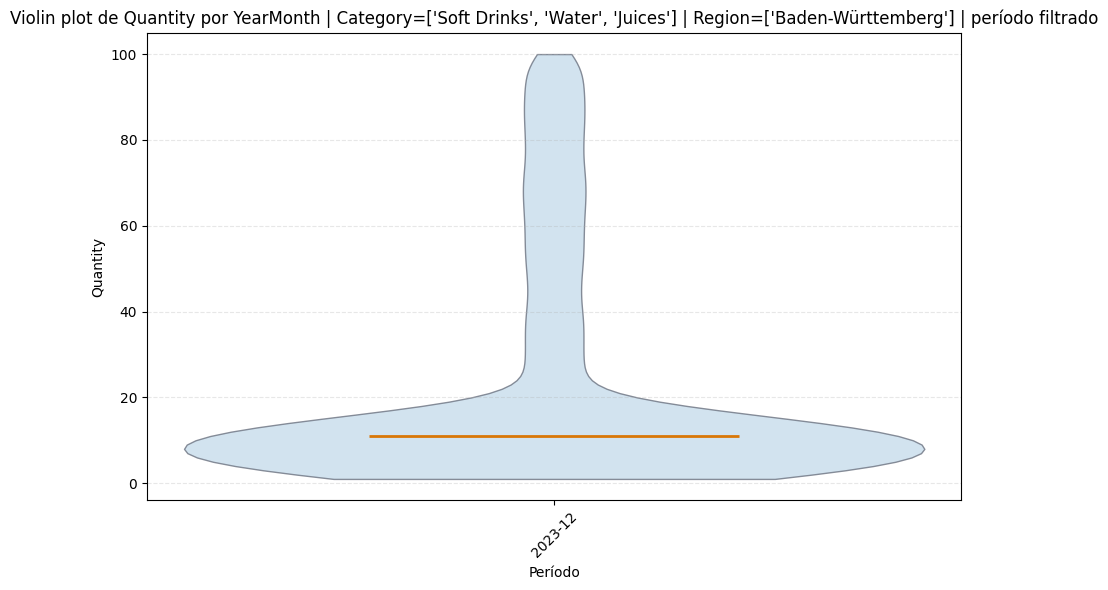

In [19]:
violin = SalesTimeViolin(df_final)

violin.plot_violin_by_period(
    value_col="Quantity",
    period="month",
    filters={
        "Category": ["Soft Drinks", "Water", "Juices"],
        "Region": ["Baden-Württemberg"]
    },
    start_date="2023-12-01",
    end_date="2024-12-31",
    use_log_scale=False
)

In [20]:
outlier_plot = SalesTimeOutlier(df_final)

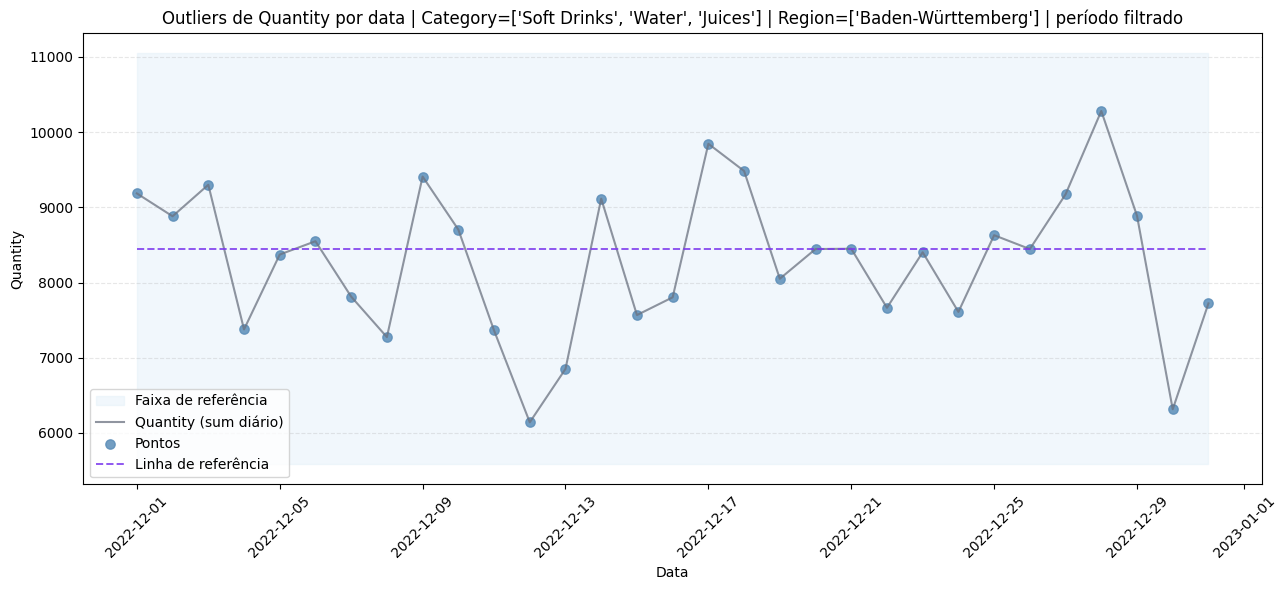

,Order_Date,Quantity,lower_limit,upper_limit,reference,is_outlier


In [21]:
resultado = outlier_plot.plot_outliers_by_period(
    value_col="Quantity",
    filters={
         "Category": ["Soft Drinks", "Water", "Juices"],
        "Region": ["Baden-Württemberg"]
    },
    start_date="2022-12-01",
    end_date="2022-12-31",
    agg="sum",
    method="iqr",
    moving_window=None
)

resultado[resultado["is_outlier"]]

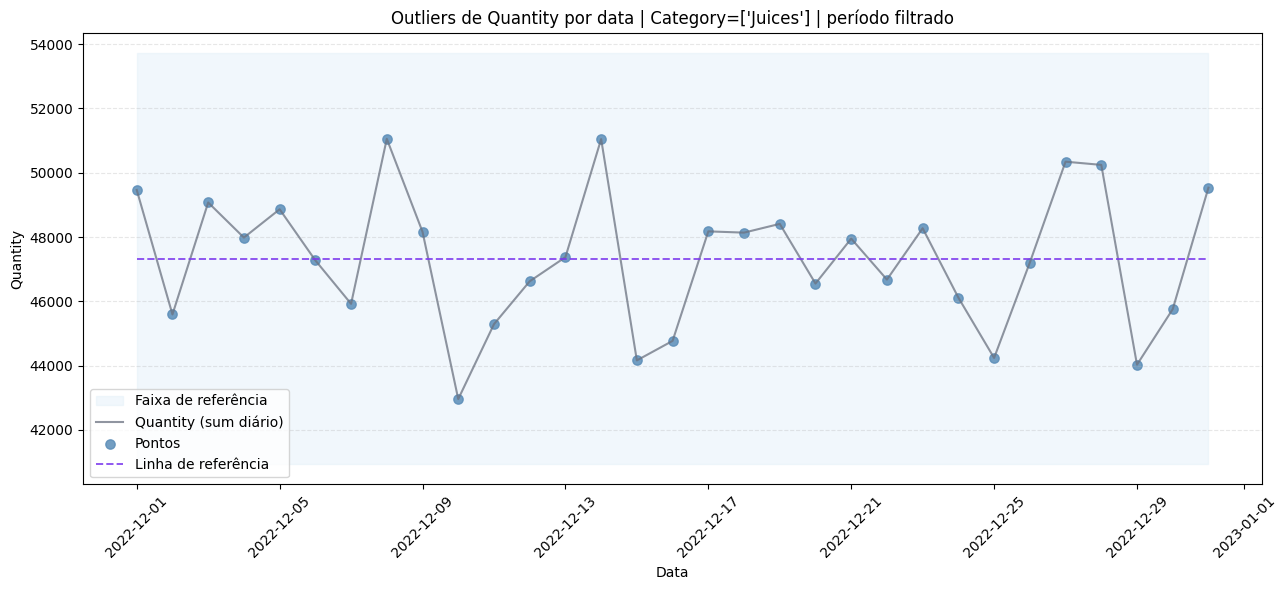

,Order_Date,Quantity,lower_limit,upper_limit,reference,is_outlier


In [22]:
resultado = outlier_plot.plot_outliers_by_period(
    value_col="Quantity",
    filters={
        "Category": ["Juices"]
    },
    start_date="2022-12-01",
    end_date="2022-12-31",
    agg="sum",
    method="zscore",
    z_threshold=3.0
)

resultado[resultado["is_outlier"]]

In [23]:
print (df_final.dtypes)

Order_ID                            object
Customer_ID                         object
Customer_Type                       object
Product                             object
Category                            object
Unit_Price                         float64
Quantity                             int64
Discount                           float64
Total_Price                        float64
Region                              object
Order_Date                  datetime64[ns]
quantity_sum                       float64
total_price_sum                    float64
unit_price_mean                    float64
discount_mean                      float64
order_count                        float64
customer_count                     float64
avg_ticket                         float64
day_of_week                          int32
month                                int32
year                                 int32
is_weekend                           int64
quantity_sum_mean_7d               float64
quantity_su

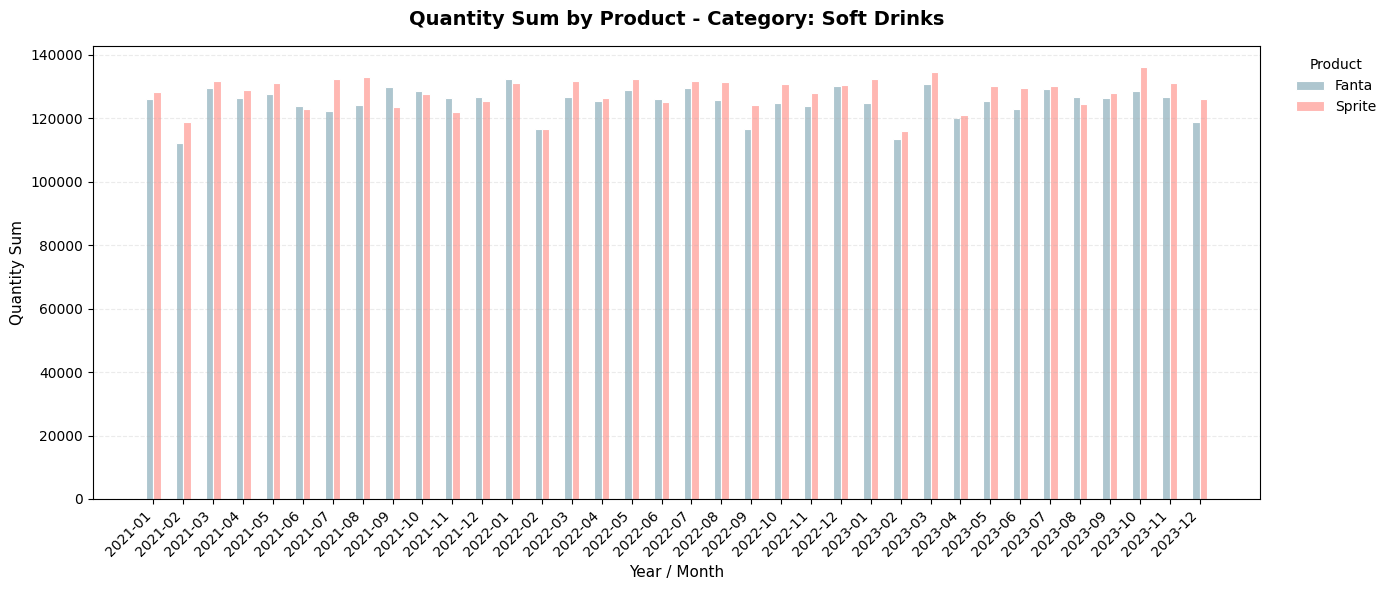

In [29]:
histogram_plotter = ProductQuantityHistogram(df_features)

result = histogram_plotter.plot(
    year=[2021,2022,2023],
    category="Soft Drinks",
    product=["Sprite", "Fanta"]
)

In [30]:

repo.set_base_path(DATA_FEATURES)
repo.save(df_features, "beverage_sales_feature.parquet")

[OK] Arquivo salvo em: D:\PROJETOS\git_repo\BEVERAGE-SALES\data\features\beverage_sales_feature.parquet
